In [ ]:
from google.colab import files

uploaded = files.upload()

Saving RELIANCE.NS_1973-05-08_2025-03-01.xlsx to RELIANCE.NS_1973-05-08_2025-03-01.xlsx


In [ ]:
import os

os.listdir("/content")

['.config', 'RELIANCE.NS_1973-05-08_2025-03-01.xlsx', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_excel(".config', 'RELIANCE.NS_1973-05-08_2025-03-01.xlsx', 'sample_data'")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: ".config', 'RELIANCE.NS_1973-05-08_2025-03-01.xlsx', 'sample_data'"

In [ ]:
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))
print("Uploaded file:", filename)

Saving RELIANCE.NS_1973-05-08_2025-03-01.xlsx to RELIANCE.NS_1973-05-08_2025-03-01 (1).xlsx
Uploaded file: RELIANCE.NS_1973-05-08_2025-03-01 (1).xlsx


In [ ]:
import pandas as pd

df = pd.read_excel(filename)

print(df.head())

                        date      open      high       low     close  \
0  1996-01-01 00:00:00+05:30  7.319124  7.358397  7.270925  7.345901   
1  1996-01-02 00:00:00+05:30   7.32805  7.363753  7.235222  7.288776   
2  1996-01-03 00:00:00+05:30  7.408381  7.745775   7.32805  7.344116   
3  1996-01-04 00:00:00+05:30  7.274495  7.297702  7.178097   7.27628   
4  1996-01-05 00:00:00+05:30  7.247718  7.247718  7.163816  7.226296   

  adj_close     volume  
0  3.353593  104121369  
1  3.327513  168743308  
2  3.352778  209323879  
3  3.321809  216900264  
4   3.29899  166708467  


In [ ]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLast 5 rows:")
print(df.tail())

Rows and columns: (7329, 7)

Column names:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

Missing values:
date         1
open         1
high         1
low          1
close        1
adj_close    1
volume       1
dtype: int64

Last 5 rows:
                       date         open         high         low  \
7324                    NaN          NaN          NaN         NaN   
7325  operatio+A7327:G7330n         open         high         low   
7326               AVERAGE    326.804309    330.41593  322.919029   
7327                MINIMUM     5.462565     5.487558    5.428648   
7328                MAXIMUM  1604.449951  1608.800049      1585.5   

            close    adj_close           volume  
7324          NaN          NaN              NaN  
7325        close    adi_close           volume  
7326   326.516915   312.722616  59388015.534407  
7327     5.487558     2.505212                0  
7328  1600.900024  1595.484985       1448889005  


In [ ]:
# Keep only rows where the date is a valid date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Remove rows where date could not be converted
df = df.dropna(subset=['date'])

# Sort the data from oldest to newest
df = df.sort_values('date').reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

Cleaned dataset shape: (7324, 7)

First 5 rows:
                       date      open      high       low     close adj_close  \
0 1996-01-01 00:00:00+05:30  7.319124  7.358397  7.270925  7.345901  3.353593   
1 1996-01-02 00:00:00+05:30   7.32805  7.363753  7.235222  7.288776  3.327513   
2 1996-01-03 00:00:00+05:30  7.408381  7.745775   7.32805  7.344116  3.352778   
3 1996-01-04 00:00:00+05:30  7.274495  7.297702  7.178097   7.27628  3.321809   
4 1996-01-05 00:00:00+05:30  7.247718  7.247718  7.163816  7.226296   3.29899   

      volume  
0  104121369  
1  168743308  
2  209323879  
3  216900264  
4  166708467  

Last 5 rows:
                          date         open         high          low  \
7319 2025-02-21 00:00:00+05:30  1228.699951         1240  1222.150024   
7320 2025-02-24 00:00:00+05:30  1216.550049      1223.25       1210.5   
7321 2025-02-25 00:00:00+05:30         1211         1221       1201.5   
7322 2025-02-27 00:00:00+05:30  1212.800049         1215  1200.650024

In [ ]:
# Select the closing price
data = df[['date', 'close']].copy()

# Calculate the 80% split point
split_index = int(len(data) * 0.8)

# Split chronologically
train = data.iloc[:split_index]
test = data.iloc[split_index:]

print("Training records:", len(train))
print("Testing records:", len(test))

print("\nTraining period:")
print(train['date'].min(), "to", train['date'].max())

print("\nTesting period:")
print(test['date'].min(), "to", test['date'].max())

Training records: 5859
Testing records: 1465

Training period:
1996-01-01 00:00:00+05:30 to 2019-03-27 00:00:00+05:30

Testing period:
2019-03-28 00:00:00+05:30 to 2025-02-28 00:00:00+05:30


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Convert dates into numerical values
X_train = (train['date'] - train['date'].min()).dt.days.values.reshape(-1, 1)
y_train = train['close'].values

X_test = (test['date'] - train['date'].min()).dt.days.values.reshape(-1, 1)
y_test = test['close'].values

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
# Make predictions for the testing period
y_pred = model.predict(X_test)

# Show the first 10 predictions
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(f"Actual: {actual:.2f} | Predicted: {predicted:.2f}")

Actual: 621.75 | Predicted: 348.26
Actual: 636.31 | Predicted: 348.45
Actual: 635.32 | Predicted: 348.50
Actual: 628.70 | Predicted: 348.55
Actual: 618.57 | Predicted: 348.59
Actual: 618.96 | Predicted: 348.64
Actual: 607.69 | Predicted: 348.78
Actual: 610.07 | Predicted: 348.83
Actual: 608.67 | Predicted: 348.88
Actual: 615.71 | Predicted: 348.93


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Use the training closing prices
train_prices = train['close'].astype(float).reset_index(drop=True)

print("Training prices:", len(train_prices))
print(train_prices.head())

Training prices: 5859
0    7.345901
1    7.288776
2    7.344116
3    7.276280
4    7.226296
Name: close, dtype: float64


In [ ]:
model_es = ExponentialSmoothing(
    train_prices,
    trend='add',
    damped_trend=True
)

model_es_fit = model_es.fit()

print("Exponential Smoothing model trained successfully!")

Exponential Smoothing model trained successfully!


In [ ]:
forecast = model_es_fit.forecast(len(test))

print("First 10 forecasts:")

for value in forecast[:10]:
    print(f"{value:.2f}")


First 10 forecasts:
617.82
617.92
618.02
618.11
618.21
618.31
618.41
618.51
618.60
618.70


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Actual testing values
actual = test['close'].astype(float).values

# Forecast values
predicted = np.array(forecast)

# Calculate evaluation metrics
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2 = r2_score(actual, predicted)

print("Model Evaluation")
print("----------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Model Evaluation
----------------
MAE  : 431.42
RMSE : 497.37
R²   : -2.3858


In [ ]:
# Check the available years
df['year'] = df['date'].dt.year

print(df['year'].value_counts().sort_index())

year
1996    262
1997    261
1998    261
1999    261
2000    260
2001    261
2002    261
2003    260
2004    260
2005    250
2006    247
2007    248
2008    246
2009    243
2010    250
2011    246
2012    245
2013    248
2014    244
2015    246
2016    246
2017    248
2018    246
2019    243
2020    251
2021    248
2022    248
2023    245
2024    246
2025     43
Name: count, dtype: int64


In [ ]:
# Create recent-period dataset
recent_data = df[df['year'] >= 2020][['date', 'close']].copy()

# Training = 2020 to 2024
train_recent = recent_data[recent_data['date'].dt.year < 2025].copy()

# Testing = 2025
test_recent = recent_data[recent_data['date'].dt.year == 2025].copy()

print("Training records:", len(train_recent))
print("Testing records:", len(test_recent))

print("\nTraining period:")
print(train_recent['date'].min(), "to", train_recent['date'].max())

print("\nTesting period:")
print(test_recent['date'].min(), "to", test_recent['date'].max())

Training records: 1238
Testing records: 43

Training period:
2020-01-01 00:00:00+05:30 to 2024-12-31 00:00:00+05:30

Testing period:
2025-01-01 00:00:00+05:30 to 2025-02-28 00:00:00+05:30


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Get training closing prices
train_prices_recent = train_recent['close'].astype(float).reset_index(drop=True)

# Build the model
model_recent = ExponentialSmoothing(
    train_prices_recent,
    trend='add',
    damped_trend=True
)

# Train the model
model_recent_fit = model_recent.fit()

print("Recent-period model trained successfully!")

Recent-period model trained successfully!


In [ ]:
# Forecast the 43 trading days in 2025
forecast_recent = model_recent_fit.forecast(len(test_recent))

print("First 10 forecasts:")

for value in forecast_recent[:10]:
    print(f"{value:.2f}")

First 10 forecasts:
1215.38
1215.38
1215.38
1215.38
1215.39
1215.39
1215.39
1215.40
1215.40
1215.40


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Training closing prices
train_prices_recent = train_recent['close'].astype(float).reset_index(drop=True)

# Build ARIMA model
arima_model = ARIMA(train_prices_recent, order=(5, 1, 0))

# Train the model
arima_fit = arima_model.fit()

print("ARIMA model trained successfully!")

ARIMA model trained successfully!


In [ ]:
# Forecast the 43 trading days of 2025
arima_forecast = arima_fit.forecast(steps=len(test_recent))

print("First 10 ARIMA forecasts:")

for value in arima_forecast[:10]:
    print(f"{value:.2f}")

First 10 ARIMA forecasts:
1214.94
1215.53
1215.41
1215.25
1215.29
1215.28
1215.30
1215.30
1215.30
1215.30


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Actual 2025 closing prices
actual_recent = test_recent['close'].astype(float).values

# ARIMA predictions
predicted_arima = np.array(arima_forecast)

# Calculate metrics
mae_arima = mean_absolute_error(actual_recent, predicted_arima)
rmse_arima = np.sqrt(mean_squared_error(actual_recent, predicted_arima))
r2_arima = r2_score(actual_recent, predicted_arima)

print("ARIMA Model Evaluation")
print("----------------------")
print(f"MAE  : {mae_arima:.2f}")
print(f"RMSE : {rmse_arima:.2f}")
print(f"R²   : {r2_arima:.4f}")

ARIMA Model Evaluation
----------------------
MAE  : 31.55
RMSE : 39.19
R²   : -1.3921


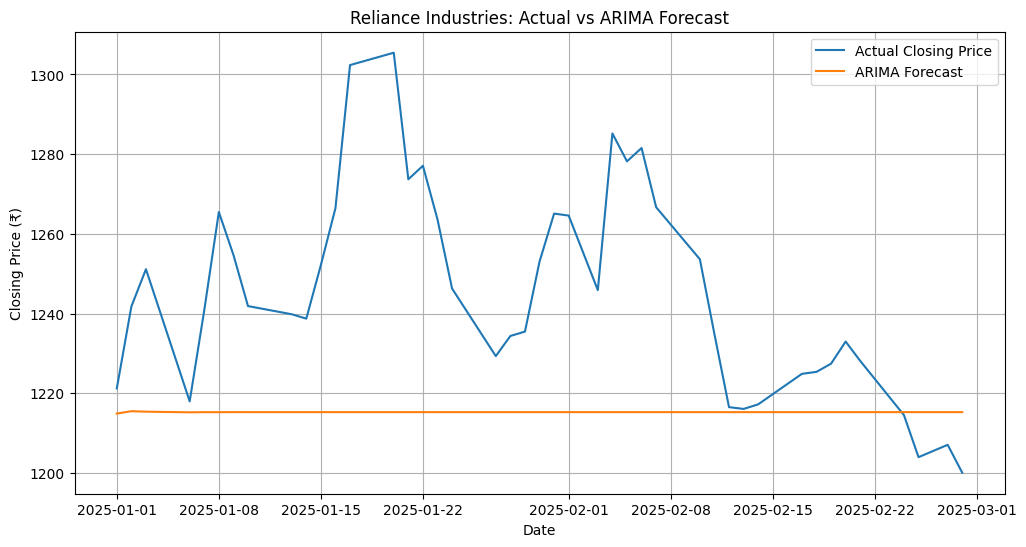

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    test_recent['date'],
    actual_recent,
    label='Actual Closing Price'
)

plt.plot(
    test_recent['date'],
    predicted_arima,
    label='ARIMA Forecast'
)

plt.title('Reliance Industries: Actual vs ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Closing Price (₹)')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Use all recent data (2020-2025) for the final model
final_data = df[df['year'] >= 2020][['date', 'close']].copy()

final_prices = final_data['close'].astype(float).reset_index(drop=True)

# Train final ARIMA model
final_arima = ARIMA(final_prices, order=(5, 1, 0))
final_arima_fit = final_arima.fit()

print("Final ARIMA model trained successfully!")

Final ARIMA model trained successfully!


In [ ]:
# Forecast the next 30 trading days
future_forecast = final_arima_fit.forecast(steps=30)

print("Next 30 forecasted closing prices:")

for i, value in enumerate(future_forecast, start=1):
    print(f"Day {i}: ₹{value:.2f}")

Next 30 forecasted closing prices:
Day 1: ₹1200.98
Day 2: ₹1200.66
Day 3: ₹1200.97
Day 4: ₹1201.01
Day 5: ₹1200.97
Day 6: ₹1200.96
Day 7: ₹1200.95
Day 8: ₹1200.96
Day 9: ₹1200.96
Day 10: ₹1200.96
Day 11: ₹1200.96
Day 12: ₹1200.96
Day 13: ₹1200.96
Day 14: ₹1200.96
Day 15: ₹1200.96
Day 16: ₹1200.96
Day 17: ₹1200.96
Day 18: ₹1200.96
Day 19: ₹1200.96
Day 20: ₹1200.96
Day 21: ₹1200.96
Day 22: ₹1200.96
Day 23: ₹1200.96
Day 24: ₹1200.96
Day 25: ₹1200.96
Day 26: ₹1200.96
Day 27: ₹1200.96
Day 28: ₹1200.96
Day 29: ₹1200.96
Day 30: ₹1200.96


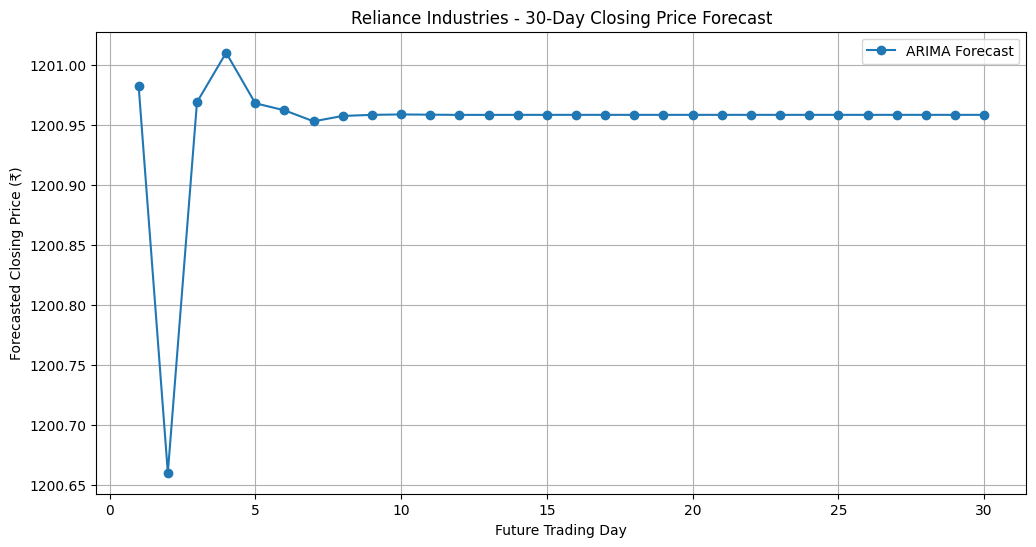

In [ ]:
import matplotlib.pyplot as plt

# Create future day numbers
future_days = range(1, 31)

plt.figure(figsize=(12, 6))

plt.plot(
    future_days,
    future_forecast,
    marker='o',
    label='ARIMA Forecast'
)

plt.title('Reliance Industries - 30-Day Closing Price Forecast')
plt.xlabel('Future Trading Day')
plt.ylabel('Forecasted Closing Price (₹)')
plt.legend()
plt.grid(True)

plt.show()